In [2]:
import numpy as np
import pandas as pd

In [4]:
bounds = np.array([
        [5, 10],  # Longitude bounds
        [0, 3],  # Latitude bounds
    ])

In [6]:
bounds[0][1]

np.int64(10)

In [7]:
data_file = r'../data/Map_village_20241227_data.csv'

In [8]:
def read_data(file_path):
    # Read the CSV file into a DataFrame
    data = pd.read_csv(file_path)
    households = data[data['Type'] == 'Household']
    pumps = data[data['Type'] == 'Hand Pump']
    return data, households, pumps

In [9]:
data, households, pumps= read_data(data_file)

In [10]:
print(pumps)

          Type        Lon        Lat  Altitude  Nb capita  Drink  Cook  \
191  Hand Pump -11.433498  10.980816       372        NaN    NaN   NaN   
192  Hand Pump -11.444274  10.990651       350        NaN    NaN   NaN   
193  Hand Pump -11.420954  11.001941       350        NaN    NaN   NaN   

     Hygiene  Laundry  Usage  
191      NaN      NaN    NaN  
192      NaN      NaN    NaN  
193      NaN      NaN    NaN  


In [11]:
print(data['Lon'].mean(), data['Lat'].mean())

-11.43402127185567 10.991749958659796


In [12]:
nb_capita = households['Nb capita'].to_numpy()
print(nb_capita)

[ 6. 10.  7.  6.  5.  5.  4.  8.  7.  7.  3. 10.  8.  5.  5.  5.  5.  6.
  6.  5.  7.  4.  5.  6.  6.  7.  5.  6.  6.  3.  7.  5.  4.  9. 10.  8.
  5.  4.  7.  6.  4.  6.  3.  9.  5.  7.  5.  6.  6.  5. 10.  7.  9.  8.
  6.  9.  4.  5.  3.  5.  6.  5.  8.  6.  5.  6.  4.  8.  4. 10.  7.  5.
  3.  8.  7.  7.  7.  4.  6.  4.  8.  7.  5.  4.  5.  5.  7.  7.  8.  6.
  4.  7.  7.  6.  7.  6.  6.  6.  3.  4.  3.  7.  5.  6.  9.  5.  6.  7.
  5.  4.  5.  5.  9.  8.  7.  8.  8.  5.  8.  6.  8.  8.  5.  4.  5.  6.
  8.  8.  3.  6.  6.  5.  4.  5.  9.  5.  6.  7.  6. 10. 10.  5.  6.  5.
  5.  3.  7.  6.  4.  5.  9.  5.  4.  6. 10.  5.  7.  7.  5.  7.  6.  7.
  7.  6.  4.  8.  5.  5.  3.  6.]


In [13]:
pos_households = households[['Lon','Lat']].to_numpy() # For f1 (sum of weighted distances)
nb_capita = households['Nb capita'].to_numpy() # Define weight factors for each distance in pos_households
pos_pumps = pumps[['Lon','Lat']].to_numpy() # For f2 (min distance)

In [14]:
import geopy.distance as geo

In [ ]:
def impact(pump_positions, x = None):
    pump_positions_copy = pump_positions.copy()
    if x == None:
        pass
    else:
        pump_positions_copy = np.concatenate((pump_positions_copy,np.array([x])),axis = 0)
    min_pump_distance = np.zeros(len(households))
    for index,household in households.iterrows():
        dist = np.zeros(len(pump_positions_copy))
        for i,pump_pos in enumerate(pump_positions_copy):
            dist[i] = geo.graphreat_circle(pump_pos, pos_households[index]).meters
        min_pump_distance[index] = np.min(dist)

    impact = np.sum(nb_capita * (min_pump_distance))
    return impact, min_pump_distance

: 

: 

: 

In [15]:
y = np.array([[-11.44,11]])
np.concatenate((pos_pumps,y), axis = 0)

array([[-11.43349811,  10.98081621],
       [-11.44427405,  10.99065103],
       [-11.42095355,  11.00194111],
       [-11.44      ,  11.        ]])

In [16]:
h = np.array([1,1])
print(type(h))
print(type(h) == 'NoneType')

<class 'numpy.ndarray'>
False


In [17]:
impact_added, min_dist_added = impact(pos_pumps,[-11.44,11.00])
impact_init, min_dist_init = impact(pos_pumps)


NameError: name 'impact' is not defined

In [ ]:
print(impact_init,impact_added)

378484.27633823245 368029.0347251879


: 

: 

: 

In [ ]:
data_dist = np.column_stack((min_dist_init,min_dist_added))

: 

: 

: 

In [18]:
data_dist = np.column_stack((min_dist_init,min_dist_added))
df = pd.DataFrame(data_dist,columns=['init','added'])

NameError: name 'min_dist_init' is not defined

In [19]:
counter = 0
for i,dist in df.iterrows():
    if dist.iloc[0] == dist.iloc[1]:
        counter +=1
    else:
        pass
print(counter)

NameError: name 'df' is not defined

In [20]:
df

NameError: name 'df' is not defined

In [21]:
import matplotlib.pyplot as plt

In [22]:
def impact(pump_positions, x = None):
    pump_positions_copy = pump_positions.copy()
    if isinstance(x, np.ndarray):
        pump_positions_copy = np.concatenate((pump_positions_copy,np.array([x])),axis = 0)
    min_pump_distance = np.zeros(len(households))
    for index,household in households.iterrows():
        dist = np.zeros(len(pump_positions_copy))
        for i,pump_pos in enumerate(pump_positions_copy):
            dist[i] = geo.great_circle(pump_pos, pos_households[index]).meters
        min_pump_distance[index] = np.min(dist)

    impact = np.sum(nb_capita * (min_pump_distance))
    return -1*impact, min_pump_distance

In [23]:
new_pump= np.array([-11.43184669,  10.98180143])
impact_new,dist_new = impact(pos_pumps,new_pump)

In [24]:
print(impact_new)

-532447.8464667689


In [25]:
print(new_pump,pos_pumps[-3])

[-11.43184669  10.98180143] [-11.43349811  10.98081621]


In [26]:
data_dist = np.column_stack((min_dist_init,dist_new))
df = pd.DataFrame(data_dist,columns=['init','added'])

NameError: name 'min_dist_init' is not defined

In [27]:
counter = 0
err = 5
for i,dist in df.iterrows():
    if dist.iloc[0] <= dist.iloc[1]+err and dist.iloc[0] >= dist.iloc[1]-err:
        counter +=1
    else:
        pass
print(counter,len(df))

NameError: name 'df' is not defined

In [28]:
print(impact_new)

-532447.8464667689


In [29]:
y = np.array([[-11.4378666,  10.99908537]])
pos_pumps = np.concatenate((pos_pumps,y), axis = 0)

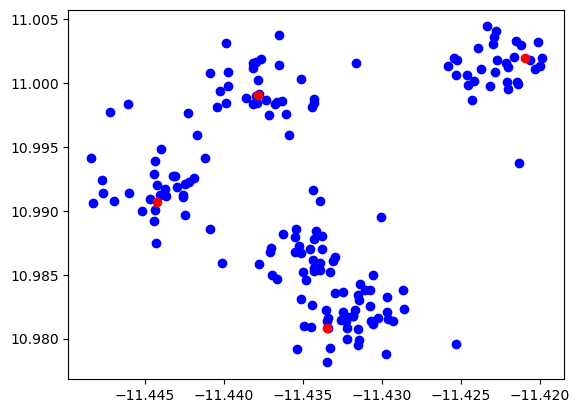

In [30]:
plt.scatter(households['Lon'].to_numpy(), households['Lat'].to_numpy(), c='blue', label='Household')
plt.scatter(pos_pumps[:,0],pos_pumps[:,1],c='red',label='pump')

plt.show()

In [59]:
pos_pumps = pumps[['Lon','Lat']].to_numpy() # For f2 (min distance)

In [62]:
def impact(pump_positions, household_positions, household_capita, max_dist, x = None):
    pump_positions_copy = pump_positions.copy()
    if isinstance(x, np.ndarray):
        pump_positions_copy = np.concatenate((pump_positions_copy,np.array([x])),axis = 0)
    within_max_distance = np.zeros(len(household_positions))
    min_distance = np.zeros(len(household_positions))
    for index,pos_houseshold in enumerate(household_positions):
        dist = np.zeros(len(pump_positions_copy))
        for i,pump_pos in enumerate(pump_positions_copy):
            dist[i] = geo.great_circle(pump_pos, household_positions[index]).meters
        min_distance[index] = np.min(dist)
        if np.min(dist) <= max_dist:
            within_max_distance[index] = 1
        else:
            within_max_distance[index] = 0

    impact = np.sum(household_capita * (within_max_distance))
    return -1*impact,within_max_distance,min_distance

In [67]:
max_distance = 800
initial_impact,init_dist,init_min_dist = impact(pos_pumps,pos_households,nb_capita,max_distance)
change_impact,change_dist,change_min_dist = impact(pos_pumps,pos_households,nb_capita,max_distance,np.array([-11.4378666,  10.99908537]))
print(initial_impact,change_impact)
print(init_dist)
print(change_dist)

-779.0 -971.0
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1.
 0. 0. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 0. 0. 0. 1. 1. 1. 1. 0.
 0. 0.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1.
 0. 0. 1. 0. 1. 1. 1. 1. 1. 1

In [64]:
data_dist = np.column_stack((init_min_dist,change_min_dist))
df = pd.DataFrame(data_dist,columns=['init','added'])

In [65]:
counter = 0
err = 5
for i,dist in df.iterrows():
    if dist.iloc[0] <= dist.iloc[1]+err and dist.iloc[0] >= dist.iloc[1]-err:
        counter +=1
    else:
        pass
print(counter,len(df))

135 170


In [16]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a sample directed graph
G = nx.Digraphraph()
graph.add_edges_from([
    ('A', 'F'),
    ('A', 'C'),
    ('B', 'D'),
    ('B', 'E'),
    ('D', 'graph')
])

# Find descendants of node 'A'
node = 'A'
descendants = nx.descendants(graph, node)
print(f"Descendants of '{node}': {descendants}")
print(f"Number of descendants: {len(descendants)}")

# # Get node levels starting from 'A'
# node_levels = get_node_levels(G, 'A')
# print(f"\nNode levels: {node_levels}")

# # Group nodes by level
# levels_dict = {}
# for node, level in node_levels.items():
#     if level not in levels_dict:
#         levels_dict[level] = []
#     levels_dict[level].append(node)

# print("\nNodes grouped by level:")
# for level in sorted(levels_dict.keys()):
#     print(f"Level {level}: {levels_dict[level]}")

Descendants of 'A': {'C', 'F'}
Number of descendants: 2


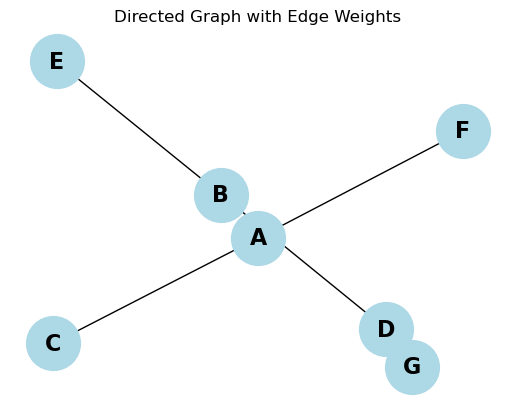

In [17]:
# Create graph with weighted edges
# G = nx.DiGraph()
# G.add_weighted_edges_from([
#     ('A', 'B', 5),
#     ('A', 'C', 3),
#     ('B', 'D', 2),
# ])

# Draw the graph
pos = nx.spring_layout(G, seed=42)

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=1500)

# Draw edges
nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=20)

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=16, font_weight='bold')

# Draw edge weights
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=12)

plt.title("Directed Graph with Edge Weights")
plt.axis('off')
plt.show()

In [19]:
print(G.nodes(data="weight", default=1))

[('A', 1), ('B', 1), ('C', 1), ('D', 1)]


In [20]:
nx.get_edge_attributes(G, 'weight')

{('A', 'B'): 5, ('A', 'C'): 3, ('B', 'D'): 2, ('C', 'D'): 4}

In [34]:
G.add_node('E',height=5)
G.add_edge('C','E',weight=4)

In [35]:
print(list(nx.bfs_edges(G, 'A')))
for parent,child in nx.bfs_edges(G, 'A'):
    if parent == 'A':
        print(f"Direct child of A: {child}")
        print(f"number of descendants of {child}: {len(nx.descendants(G, child))}")
        print(f'Edge length: {G[parent][child]["weight"]}')

[('A', 'B'), ('A', 'C'), ('B', 'D'), ('C', 'E')]
Direct child of A: B
number of descendants of B: 1
Edge length: 5
Direct child of A: C
number of descendants of C: 1
Edge length: 3


In [42]:
G.add_nodes_from([('E', {"height":10,"time":4})])

In [45]:
G.nodes(data=True)

NodeDataView({'A': {}, 'B': {}, 'C': {}, 'D': {}, 'E': {'height': 10, 'time': 4}})

In [49]:
def get_node_families_dfs_by_level(G):
    """Get nodes grouped by family and level using DFS from root nodes."""
    # Find all root nodes
    root_nodes = [node for node in G.nodes() if G.in_degree(node) == 0]
    
    families = []
    
    for root in root_nodes:
        family_dict = {}
        visited = set()
        
        def dfs(node, level):
            if node not in visited:
                visited.add(node)
                # Add node to the level dictionary
                if level not in family_dict:
                    family_dict[level] = []
                family_dict[level].append(node)
                
                # Recursively visit successors at the next level
                for successor in G.successors(node):
                    dfs(successor, level + 1)
        
        dfs(root, 0)
        if family_dict:
            families.append(family_dict)
    
    return families

# Example
G = nx.DiGraph()
G.add_edges_from([
    ('A', 'B'),
    ('B', 'D'),
    ('B', 'E'),
    ('C', 'F'),
    ('F', 'G')
])

families = get_node_families_dfs_by_level(G)
print("Node Families by Level (DFS):")
for i, family_dict in enumerate(families):
    print(f"Family {i+1}:")
    for level in sorted(family_dict.keys()):
        print(f"  Level {level}: {family_dict[level]}")

Node Families by Level (DFS):
Family 1:
  Level 0: ['A']
  Level 1: ['B']
  Level 2: ['D', 'E']
Family 2:
  Level 0: ['C']
  Level 1: ['F']
  Level 2: ['G']


In [50]:
G.get_edge_data('A','B')

{}

In [9]:
import numpy as np
from scipy.interpolate import griddata, RBFInterpolator
import pandas as pd
import matplotlib.pyplot as plt
import geopy.distance as geo

In [11]:
def build_altitude_interpolator(df, kernel='linear'):
    """
    Build an interpolator that can predict altitude at any lat/lon
    using Radial Basis Function interpolation (works outside convex hull).
    
    Parameters:
        df (pd.DataFrame): must have 'lat', 'lon', 'alt' columns
        kernel (str): RBF kernel ('linear', 'cubic', 'thin_plate_spline', etc.)
        
    Returns:
        function: takes (lon, lat) and returns predicted altitude
    """
    # Prepare training points and values
    points = np.column_stack((df['Lat'], df['Lon']))
    values = df['Altitude'].values
    
    # Build RBF interpolator
    rbf = RBFInterpolator(points, values, kernel=kernel)
    
    def get_alt(point):
        (lon,lat) = point
        # Accepts scalars or arrays
        query_points = np.column_stack((np.atleast_1d(lat), np.atleast_1d(lon)))
        result = rbf(query_points)
        # Return scalar if scalar input
        return result if np.ndim(lat) > 0 else result[0]
    
    return get_alt

In [12]:
def read_data_gogma(file_path):
    data_households, data_sources = pd.read_excel(
        file_path,
        sheet_name=['Position surveyed household (hh','Position water sources'],
        header=None).values()
    data_sources = data_sources.iloc[:,:5]
    data_sources.columns = ['ID','Name','Lon','Lat','Altitude']
    data_sources['Type'] = data_sources['Name'].str[1]
    data_sources = data_sources[(data_sources['Type']=='B') | (data_sources['Type']=='W')].drop('Name',axis=1)
    data_sources['Type'] = data_sources['Type'].replace('B','Borehole')
    data_sources['Type'] = data_sources['Type'].replace('W','Open Well')
    
    data_households.columns = ['ID','Lat','Lon','Altitude']
    data_household_capita = pd.read_excel(file_path,sheet_name='Choice source before install',usecols='A,F,G').iloc[1:]
    data_household_capita.columns = ['ID','Reading','Nb capita']
    data_household_capita = data_household_capita.sort_values(by='Reading',ascending=True)
    data_household_capita = data_household_capita.drop_duplicates(subset='ID').sort_values(by='ID').iloc[:-1].drop('Reading',axis=1)
    
    data_households['Type'] = 'Household'
    data_households = pd.merge(data_households, data_household_capita, on='ID', how='inner')    
    
    data = pd.concat([data_households,data_sources],ignore_index=True)
    households = data_households
    pumps = data_sources[data_sources['Type']=='Borehole']
    open_wells = data_sources[data_sources['Type']=='Open Well']
    
    
    return data,households,pumps,open_wells

In [13]:
# Import data and define arrays (may need to rewrite read function depending on input)
data_file = r'..\src\data\DO_NOT_DISTRIBUTE_DATA_GOGMA.xlsx'
data,households,pumps,open_wells = read_data_gogma(data_file)
pos_households = households[['Lon','Lat']].to_numpy() 
nb_capita = households['Nb capita'].to_numpy()
pos_pumps = pumps[['Lon','Lat']].to_numpy()
bounds = np.array([
    [data['Lon'].min(), data['Lat'].min()],  # Min bounds
    [data['Lon'].max(), data['Lat'].max()],  # Max bounds
])

# Create gridpoints for relief plot
grid_x, grid_y = np.mgrid[data['Lon'].min():data['Lon'].max():200j, 
                        data['Lat'].min():data['Lat'].max():200j]
grid_z = griddata((data['Lon'], data['Lat']), data['Altitude'], (grid_x, grid_y), method='cubic')

# Create interpolator for altitude
get_alt = build_altitude_interpolator(data)

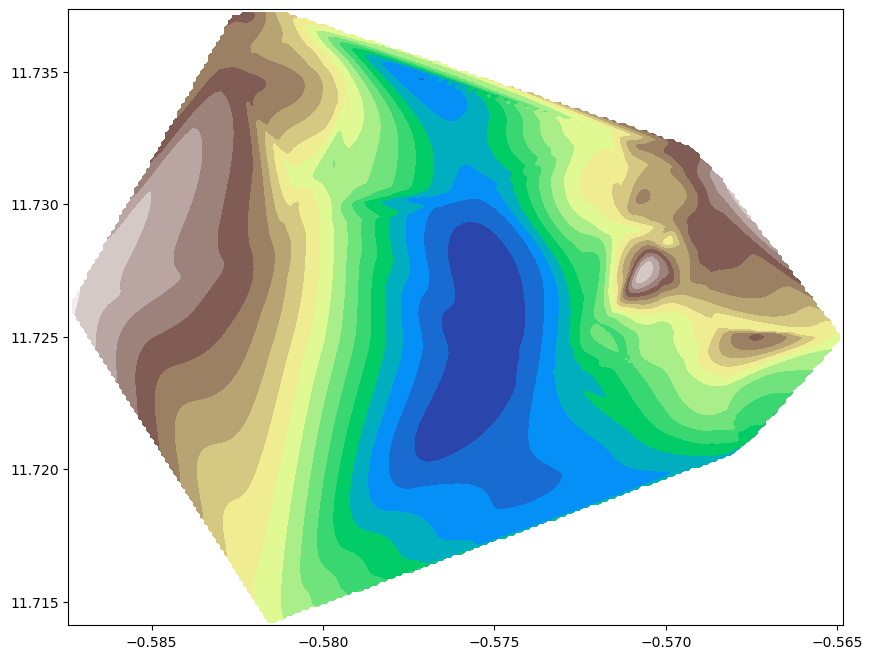

In [14]:
fig,ax = plt.subplots(figsize=(10,8))
ax.contourf(grid_x, grid_y, grid_z, levels=20, cmap='terrain')

In [15]:
def pump_distance(
    pump_positions: np.ndarray,
    household_positions: np.ndarray,
    x: np.ndarray|None = None,
    ):
    """_summary_

    Args:
        pump_positions (np.ndarray): 
            Array of [lon, lat] positions of pumps
        household_positions (np.ndarray): 
            Array of [lon, lat] positions of households
        x (np.ndarray, optional): 
            Positions of potential new Fountains [lon,lat]. Defaults to None.
        
    Returns:
        min_pump_distance (np.ndarray): 
            Array of distances (len(household_positions))
            to closest pump for each household
        min_pump_distance_index (np.ndarray): 
            Array (len(household_positions)) of 
            index of closest pump for each household
    """
    
    # Make copy and add x to pump array if it exists
    pump_positions_copy = pump_positions.copy()
    if isinstance(x, np.ndarray):
        pump_positions_copy = np.vstack((pump_positions_copy,np.array(x)))
        
    # Create arrays to assign values to
    min_pump_distance = np.zeros(len(household_positions))
    min_pump_distance_index = np.zeros(len(household_positions))
    
    for index,pos_household in enumerate(household_positions):
        dist = np.zeros(len(pump_positions_copy))
        for i,pump_pos in enumerate(pump_positions_copy):
            dist[i] = geo.great_circle(pump_pos, pos_household).meters
        min_pump_distance[index] = np.min(dist)
        min_pump_distance_index[index] = np.argmin(dist)
    
    return min_pump_distance, min_pump_distance_index

In [16]:
min_pump_distance, min_pump_distance_index = pump_distance(pos_pumps,pos_households)
unique_pump_indices = np.unique(min_pump_distance_index)

In [17]:
household_consumption = []
consumption_dict = {i: 0 for i in unique_pump_indices}
for i, pump in enumerate(min_pump_distance_index):
    if pump in consumption_dict:
        consumption_dict[pump] += nb_capita[i]*10
        household_consumption.append(nb_capita[i]*10)
    

In [18]:
print(consumption_dict)

{np.float64(1.0): 2470, np.float64(2.0): 1010, np.float64(3.0): 270, np.float64(4.0): 1240, np.float64(6.0): 670, np.float64(7.0): 1250, np.float64(9.0): 570}


In [77]:
print(np.min(household_consumption),np.max(household_consumption))

20 230


In [73]:
path = r"..\src\data\usage_profile.xlsx"
usage_profile = pd.read_excel(path,index_col="Heure")

In [74]:
means = usage_profile["moyenne"].to_numpy()
std_devs = usage_profile["std_dev"].to_numpy()

In [106]:
def generate_value_gaussian(mean, std_dev, rng):
    return rng.normal(loc=mean, scale=std_dev)
def return_interval(value, interval):
    return divmod(value, interval)
def second_starting(size, rng):
    return rng.uniform(0, 3479, size=size)
    

In [111]:
import math

In [109]:
for i,k in enumerate(consumption_dict.keys()):
    rng = np.random.default_rng(i)
    usage_profile[f"Pump_{k}_dist"] = usage_profile.apply(lambda row: generate_value_gaussian(row["moyenne"], row["std_dev"], rng), axis=1).clip(lower=0)
    usage_profile[f"Pump_{k}_dist"] = usage_profile[f"Pump_{k}_dist"]/sum(usage_profile[f"Pump_{k}_dist"])
    usage_profile[f"Pump_{k}_consumption"] = usage_profile[f"Pump_{k}_dist"] * consumption_dict[k]
    usage_profile[f"Pump_{k}_flowing_times"] = usage_profile[f"Pump_{k}_consumption"] / (0.3*60) # time flowing in minutes if flow rate is 0.3 L/s
    usage_profile[f"Pump_{k}_intervals"] = usage_profile.apply(lambda row: return_interval(row[f"Pump_{k}_flowing_times"], 2), axis=1) # number of 2 minute intervals and remainder
    usage_profile[f"Pump_{k}_intervals_start"] = usage_profile.apply(lambda row: second_starting(int(row[f"Pump_{k}_intervals"][0])+1, rng), axis=1)
    for j in range(usage_profile.shape[0]):
        for t in usage_profile["Pump_{k}_intervals_start"][j]:
            usage_profile.loc[j, f"Pump_{k}_on_times"] = math.floor(t)

In [154]:
def generate_pump_on_times(consumption_dict, means, std_devs):
    # Generate pump on-times with proper handling of remainders and no overlap into next hour
    pump_on_times = {}

    for i, k in enumerate(consumption_dict.keys()):
        rng = np.random.default_rng(i)
        
        # Generate consumption distribution
        dist = np.array([generate_value_gaussian(m, s, rng) for m, s in zip(means, std_devs)]).clip(min=0)
        dist = dist / dist.sum()
        
        # Calculate consumption and flowing times
        consumption = dist * consumption_dict[k]
        flowing_times = consumption / (0.3 * 60)  # minutes
        
        # For each hour, generate intervals with durations and random start times
        on_times_dict = {}
        for hour_idx, flowing_time in enumerate(flowing_times):
            remaining_time = flowing_time
            while remaining_time > 0.01:  # Small threshold for floating point
                # Interval is either 2 minutes or whatever is left
                interval_duration = min(2, remaining_time)
                remaining_time -= interval_duration
                
                # Generate random start time that doesn't overlap into next hour
                # Max start (in seconds) = 60 mins - interval_duration
                max_start_seconds = (60 - interval_duration) * 60
                if max_start_seconds > 0:
                    start_second = math.floor(rng.uniform(0, max_start_seconds))
                    interval_duration_sec = math.floor(interval_duration * 60)  # Convert to seconds
                    on_times_dict[hour_idx] = on_times_dict.get(hour_idx, []) + [(start_second, interval_duration_sec)]
        
        pump_on_times[k] = on_times_dict

    # Convert to DataFrame with hours as index and pump columns
    data = {f'pump_{k}': {h: pump_on_times[k].get(h,) for h in range(24)} 
            for k in pump_on_times.keys()}
    return pd.DataFrame(data)

df_on_times = generate_pump_on_times(consumption_dict, means, std_devs)
display(df_on_times)

,pump_1.0,pump_2.0,pump_3.0,pump_4.0,pump_6.0,pump_7.0,pump_9.0
0,None,None,None,None,None,None,None
1,None,None,None,None,None,None,None
2,None,None,None,None,None,None,None
3,None,None,None,None,None,None,None
4,None,None,None,None,None,None,None
5,None,None,None,None,None,None,None
6,"[(2141, 120), (1335, 120), (3470, 120), (3413,...","[(3346, 120), (2590, 25)]","[(1132, 40)]","[(3122, 98)]","[(1744, 96)]","[(2363, 120), (3070, 71)]","[(374, 94)]"
7,"[(2263, 120), (2395, 120), (1353, 120), (470, ...","[(1883, 120), (963, 120), (570, 49)]","[(3253, 79)]","[(2036, 120), (1640, 120), (2751, 41)]","[(1717, 120), (1771, 58)]","[(791, 120), (3116, 120), (3115, 27)]","[(3014, 120), (496, 46)]"
8,"[(1690, 120), (3095, 120), (3250, 120), (1245,...","[(3375, 120), (1795, 120), (403, 120), (2239, 7)]","[(1650, 95)]","[(105, 120), (2460, 120), (1320, 72)]","[(3335, 120), (1253, 17)]","[(64, 120), (2462, 120), (4, 120), (1751, 120)...","[(1530, 120), (2081, 53)]"
9,"[(1175, 120), (1362, 120), (3098, 120), (790, ...","[(2702, 120), (2133, 120), (3192, 120), (142, 2)]","[(2444, 76)]","[(316, 120), (2298, 120), (3241, 120), (721, 1...","[(778, 120), (1816, 120), (2306, 3)]","[(707, 120), (1130, 120), (2805, 120), (1101, ...","[(1110, 120), (1478, 63)]"


In [153]:
# Check for overlaps among a specific set of pumps (n-way overlaps)
def check_n_pump_overlaps(df_on_times, pump_keys, min_overlap_pumps=2):
    """
    Check for periods where specified pumps overlap.
    
    Parameters:
        df_on_times: DataFrame with hours as index and pump columns
        pump_keys: List of pump keys to check for overlaps
        min_overlap_pumps: Minimum number of pumps that must overlap (default 2)
    
    Returns:
        DataFrame with all overlapping periods showing which pumps overlap and when
    """
    overlaps = []
    
    for hour in range(24):
        # Get all periods for each pump in this hour
        pump_periods = {}
        for pump_key in pump_keys:
            periods = df_on_times.loc[hour, f'pump_{pump_key}']
            if periods:
                pump_periods[pump_key] = [(start, start + dur) for start, dur in periods]
        
        if len(pump_periods) < min_overlap_pumps:
            continue
        
        # Find all overlapping regions by checking all combinations
        # Create a list of time intervals and which pumps are active
        events = []
        for pump_key, periods in pump_periods.items():
            for start, end in periods:
                events.append(('start', start, pump_key))
                events.append(('end', end, pump_key))
        
        if not events:
            continue
        
        # Sort events by time
        events.sort(key=lambda x: (x[1], x[0] == 'end'))  # ends before starts at same time
        
        # Track which pumps are currently active
        active_pumps = set()
        overlap_regions = []
        
        for i, (event_type, time, pump_key) in enumerate(events):
            if event_type == 'start':
                active_pumps.add(pump_key)
                
                # If we now have min_overlap_pumps active, mark start of overlap region
                if len(active_pumps) == min_overlap_pumps:
                    overlap_start = time
            else:  # end
                if len(active_pumps) >= min_overlap_pumps:
                    # We're ending an overlap region
                    overlap_regions.append({
                        'hour': hour,
                        'overlap_start': overlap_start,
                        'overlap_end': time,
                        'overlap_duration': time - overlap_start,
                        'active_pumps': tuple(sorted(active_pumps)),
                        'num_overlapping': len(active_pumps)
                    })
                
                active_pumps.discard(pump_key)
        
        overlaps.extend(overlap_regions)
    
    if overlaps:
        df_overlaps = pd.DataFrame(overlaps)
        # Expand active_pumps column to show pump names
        df_overlaps['pumps'] = df_overlaps['active_pumps'].apply(lambda x: ', '.join([str(p) for p in x]))
        return df_overlaps
    else:
        return pd.DataFrame()

# Example: Check specific pumps for overlaps
pump_list = ['1.0', '2.0']  # Specify which pumps to check
df_overlap_result = check_n_pump_overlaps(df_on_times, pump_list, min_overlap_pumps=2)

if len(df_overlap_result) > 0:
    print(f"Found overlapping periods among pumps {pump_list}:")
    display(df_overlap_result[['hour', 'overlap_start', 'overlap_end', 'overlap_duration', 'pumps', 'num_overlapping']])
    print(f"\nTotal overlapping time (seconds): {df_overlap_result['overlap_duration'].sum()}")
else:
    print(f"No overlapping periods found among pumps {pump_list}")


Found overlapping periods among pumps ['1.0', '2.0']:


,hour,overlap_start,overlap_end,overlap_duration,pumps,num_overlapping
0,6,3413,3466,53,"1.0, 2.0",2
1,7,570,590,20,"1.0, 2.0",2
2,7,1079,1083,4,"1.0, 2.0",2
3,7,1883,1948,65,"1.0, 2.0",2
4,8,1795,1810,15,"1.0, 2.0",2
5,9,2168,2253,85,"1.0, 2.0",2
6,9,3192,3218,26,"1.0, 2.0",2
7,11,216,323,107,"1.0, 2.0",2
8,18,3050,3117,67,"1.0, 2.0",2



Total overlapping time (seconds): 442


In [137]:
on_time_array = np.zeros((24*60*60, len(pump_on_times.keys())))
for i,pump in enumerate(df_on_times.columns):
    for hour in df_on_times.index:
        for start,duration in df_on_times.loc[hour, pump] if df_on_times.loc[hour, pump] else []:
            on_time_array[hour*3600 + start : hour*3600 + start + duration, i] = 1

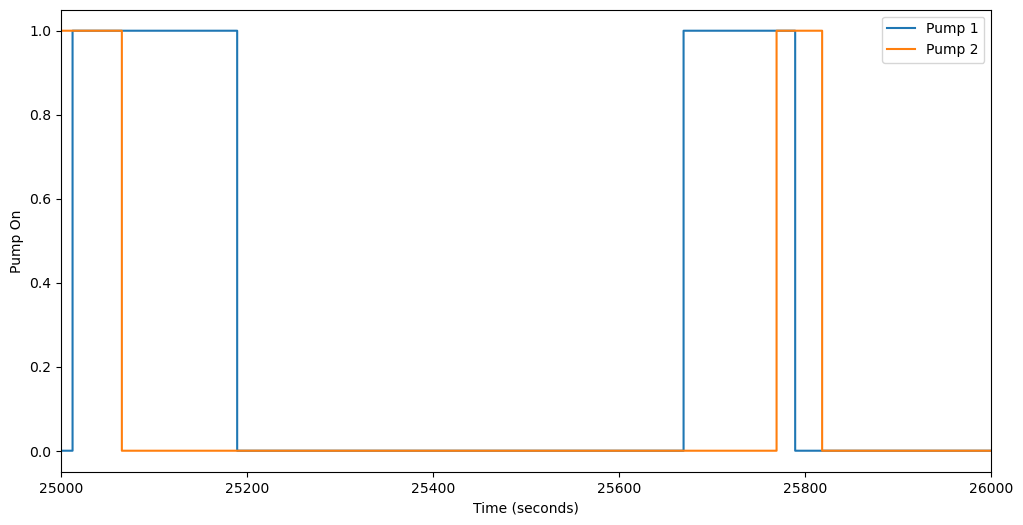

In [150]:
fig,ax = plt.subplots(figsize=(12,6))
for i in [0,1]:#range(len(pump_on_times.keys())):
    ax.step(range(24*60*60),on_time_array[:,i] ,label=f'Pump {i+1}')#+ i*1.5
    
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Pump On')
ax.set_xlim(25000,26000)
ax.legend()
plt.show()


In [56]:
usage_profile["value"] = usage_profile.apply(lambda row: generate_value_gaussian(row["moyenne"], row["std_dev"]), axis=1)
usage_profile["value"] = usage_profile["value"]/np.sum(usage_profile["value"])
profile_distribution = usage_profile["value"].to_numpy()
time = usage_profile.index.to_numpy()

In [58]:
usage_profile.head(10)

,moyenne,rel +/- std dev,std_dev,value
Heure,,,,
0,0.000,0.00,0.00000,0.000000
1,0.000,0.00,0.00000,0.000000
2,0.000,0.00,0.00000,0.000000
3,0.000,0.00,0.00000,0.000000
4,0.000,0.00,0.00000,0.000000
5,0.000,0.00,0.00000,0.000000
6,0.050,0.25,0.01250,0.057729
7,0.075,0.25,0.01875,0.089615
8,0.100,0.25,0.02500,0.079188


In [7]:
print(profile_distribution)

[0.         0.         0.         0.         0.         0.
 0.05814652 0.0730637  0.10315725 0.12654311 0.05017152 0.05287966
 0.01982953 0.02176884 0.05257951 0.11183387 0.12491168 0.10098813
 0.10412668 0.         0.         0.         0.         0.        ]


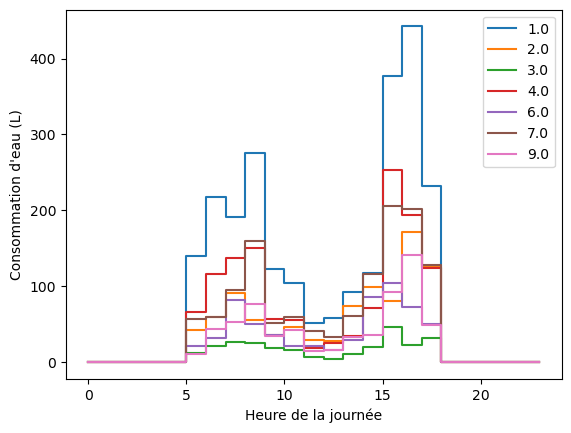

In [26]:
fix,ax = plt.subplots()
profile_dict = {}
rng = np.random.default_rng(45)
for key, value in consumption_dict.items():
    profile_dict[key] = value * rng.normal(loc=means, scale=std_devs)
    ax.step(time, profile_dict[key], label = key)
    
ax.set_ylabel("Consommation d'eau (L)")
ax.set_xlabel("Heure de la journée")
ax.legend()
plt.show()

In [27]:
# assuming constant flow rate of 0.3l/s
consumption_rate = 0.3  # liters per second
consumption_time = {key: value / consumption_rate / 60 for key, value in consumption_dict.items()}
print(consumption_time) # minutes of consumption

{np.float64(1.0): 137.22222222222223, np.float64(2.0): 56.111111111111114, np.float64(3.0): 15.0, np.float64(4.0): 68.8888888888889, np.float64(6.0): 37.22222222222222, np.float64(7.0): 69.44444444444444, np.float64(9.0): 31.666666666666668}


In [28]:
open_time_at15 = {}
for k in profile_dict.keys():
    open_time_at15[k] = profile_dict[k][16]/(consumption_rate*60*60)

In [29]:
print(open_time_at15)

{np.float64(1.0): np.float64(0.3485236367028062), np.float64(2.0): np.float64(0.07501921730239834), np.float64(3.0): np.float64(0.04269611504791355), np.float64(4.0): np.float64(0.23414140485108068), np.float64(6.0): np.float64(0.09703542028789088), np.float64(7.0): np.float64(0.19002353530473756), np.float64(9.0): np.float64(0.08581868025617613)}


In [11]:
import pandas as pd
import pickle
import networkx as nx
import matplotlib.pyplot as plt

In [12]:
file_path = r'..\src\Output\20260128_143427_data_output.xlsx'
pkl_file_path = r'..\src\Output\20260128_143427_pipe_data_output.pkl'
df = pd.read_excel(file_path, sheet_name='2_fountains')
pipe_data = pickle.load(open(pkl_file_path,'rb'))

In [35]:
X = tuple(df.iloc[3,:6].to_numpy())
print(X)
for key in pipe_data[1].keys():
    if np.allclose(X, key):
        G = pipe_data[1][key].copy()
        

edges = G.edges(data=True)
for edge in edges:
    print("now")
    print(G.add_edge(*edge[0:2],running_cost = 5))

(np.float64(10.0), np.float64(11.0), np.float64(-0.5818106853411348), np.float64(11.73225821770895), np.float64(-0.5799765887790898), np.float64(11.73124050838761))
now
None
now
None


In [36]:
print(edges)

[(10, 'N0', {'weight': 831.0966349660094, 'flow_schedule': [{'start': 21773, 'duration': 2, 'flow_multiplier': 1}, {'start': 23197, 'duration': 10, 'flow_multiplier': 1}, {'start': 24332, 'duration': 120, 'flow_multiplier': 1}, {'start': 25921, 'duration': 120, 'flow_multiplier': 1}, {'start': 27008, 'duration': 16, 'flow_multiplier': 1}, {'start': 28183, 'duration': 89, 'flow_multiplier': 1}, {'start': 30326, 'duration': 70, 'flow_multiplier': 1}, {'start': 30782, 'duration': 18, 'flow_multiplier': 1}, {'start': 32832, 'duration': 66, 'flow_multiplier': 1}, {'start': 34583, 'duration': 120, 'flow_multiplier': 1}, {'start': 35968, 'duration': 15, 'flow_multiplier': 1}, {'start': 36648, 'duration': 120, 'flow_multiplier': 1}, {'start': 37789, 'duration': 1, 'flow_multiplier': 1}, {'start': 38846, 'duration': 9, 'flow_multiplier': 1}, {'start': 41538, 'duration': 9, 'flow_multiplier': 1}, {'start': 41835, 'duration': 7, 'flow_multiplier': 1}, {'start': 42242, 'duration': 120, 'flow_multi

In [70]:
edges = G.edges(data=True)
for edge in edges:
    for flow in edge[2]['flow_schedule']:
        if flow['flow_multiplier']>len(edges):
            print(edge)

In [48]:
# 1. Get all nodes in the lineage
path_nodes = nx.ancestors(G, 'N1') | {'N1'}

# 2. Get all edges connecting those nodes
path_edges = G.subgraph(path_nodes).edges()

print(list(path_edges))

[(8, 'N0'), ('N0', 'N1')]


In [89]:
def calculate_flow_multiplier(intervals):
    """
    Input: List of (start, end) tuples.
    Output: List of (start, end, count) showing flow depth.
    """
    events = []
    for start, end in intervals:
        events.append((start, 1))  # Flow starts (+1)
        events.append((end, -1))   # Flow ends (-1)

    # Sort by time. If times are equal, process start (+1) before end (-1)
    events.sort()

    processed_profile = []
    current_depth = 0
    prev_time = events[0][0]

    for time, change in events:
        if time > prev_time:
            # Record the interval we just finished traversing
            if current_depth > 0:
                processed_profile.append({
                    'start': prev_time,
                    'end': time,
                    'flow_multiplier': current_depth 
                })
        
        current_depth += change
        prev_time = time
        
    return processed_profile


def assign_flow_to_edges(graph):
    
    # 1. Initialize a temporary list on every edge to hold raw time data
    for u, v in graph.edges():
        graph[u][v]['raw_intervals'] = []

    # 2. Iterate through every node to find demand
    for node in graph.nodes():
        node_data = graph.nodes[node]
        print(f"Processing node {node}...")
        
        if 'on_times' in node_data and node_data['on_times']:
            my_intervals = []
            
            # Iterate through the Hours (keys) and Times (values)
            for hour_key, time_list in node_data['on_times'].items():
                for (start_sec, duration) in time_list:
                    
                    # CONVERSION: Turn relative hour times into absolute seconds of the day
                    # Formula: (Hour * 3600) + Seconds
                    absolute_start = (hour_key * 3600) + start_sec
                    absolute_end = absolute_start + duration
                    
                    my_intervals.append((absolute_start, absolute_end))
            
            # 3. Find the upstream edges for this specific node
            # Using the subgraph approach we discussed earlier
            ancestors = nx.ancestors(graph, node) | {node}
            path_edges = graph.subgraph(ancestors).edges()
            print(path_edges if path_edges else "No edges...")
            
            # 4. Add this node's intervals to ALL those upstream edges
            for u, v in path_edges:
                print(f"Adding intervals to edge {u} -> {v}")
                graph[u][v]['raw_intervals'].extend(my_intervals)
                
    # 5. Final Pass: Calculate the overlaps for each edge
    for u, v in graph.edges():
        raw = graph[u][v].pop('raw_intervals') # Remove raw data to save memory
        if raw:
            # Run the helper function to get the "2x", "3x" markers
            graph[u][v]['flow_schedule'] = calculate_flow_multiplier(raw)
        else:
            graph[u][v]['flow_schedule'] = []
        
        
    return graph

In [70]:
graph_out = assign_flow_to_edges(G)
# G.edges()[(8,'N0')]

In [71]:
def plot_flow_schedule(schedule):
    """
    Plots the flow multiplier against time based on a schedule of start/end intervals.
    
    Args:
        schedule (list): A list of dictionaries, where each dictionary contains:
                         'start' (int/float), 'end' (int/float), and 'flow_multiplier' (int/float).
    """
    # Sort the schedule by start time to ensure correct plotting order
    schedule = sorted(schedule, key=lambda x: x['start'])
    
    x_coords = []
    y_coords = []
    
    if not schedule:
        print("Empty schedule provided.")
        return
    
    # Start the plot at the beginning of the first interval, rising from 0
    last_end = schedule[0]['start']
    x_coords.append(last_end)
    y_coords.append(0)
    
    for item in schedule:
        start = item['start']
        end = item['end']
        multiplier = item['flow_multiplier']
        
        # If there is a gap between the last end time and the current start time,
        # the flow multiplier drops to 0 during that gap.
        if start > last_end:
            x_coords.append(last_end)
            y_coords.append(0)
            x_coords.append(start)
            y_coords.append(0)
        
        # Add points for the current interval (step up/down to the multiplier value)
        x_coords.append(start)
        y_coords.append(multiplier)
        x_coords.append(end)
        y_coords.append(multiplier)
        
        last_end = end

    # Return to 0 after the last interval ends
    x_coords.append(last_end)
    y_coords.append(0)
    
    # Plotting configuration
    plt.figure(figsize=(15, 6))
    plt.plot(x_coords, y_coords, marker='', linestyle='-', linewidth=2)
    plt.fill_between(x_coords, y_coords, alpha=0.3)
    plt.title('Flow Multiplier Schedule')
    plt.xlabel('Time')
    plt.ylabel('Flow Multiplier')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.xlim(23300,23500)
    plt.show()

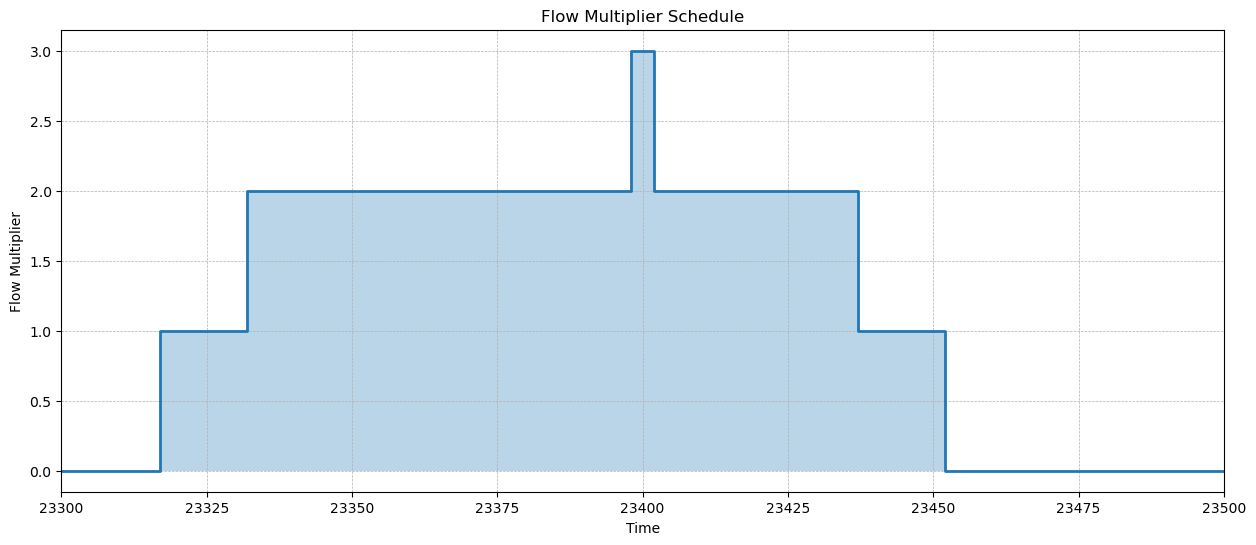

In [72]:
plot_flow_schedule(graph_out.edges()[(8,'N0')]['flow_schedule'])

In [1]:
file_path = r'..\src\Output\20260122_115627_data_output.xlsx'
pkl_file_path = r'..\src\Output\20260122_115627_pipe_data_output.pkl'
df = pd.read_excel(file_path, sheet_name='1_fountains')
pipe_data = pickle.load(open(pkl_file_path,'rb'))

NameError: name 'pd' is not defined

In [97]:
g_check = pipe_data[0][6]
print(g_check.edges(data=True))
ancestors = nx.ancestors(g_check, 'N0') | {'N0'}
path_edges = g_check.subgraph(ancestors).edges()
print(path_edges)

[(1, 'N0', {'weight': 349.87355430685835, 'flow_schedule': [{'start': 22417, 'end': 22420, 'flow_multiplier': 1}, {'start': 23963, 'end': 24083, 'flow_multiplier': 1}, {'start': 24627, 'end': 24747, 'flow_multiplier': 1}, {'start': 25264, 'end': 25364, 'flow_multiplier': 1}, {'start': 28235, 'end': 28316, 'flow_multiplier': 1}, {'start': 28316, 'end': 28355, 'flow_multiplier': 2}, {'start': 28355, 'end': 28436, 'flow_multiplier': 1}, {'start': 28804, 'end': 28924, 'flow_multiplier': 1}, {'start': 29507, 'end': 29627, 'flow_multiplier': 1}, {'start': 29946, 'end': 30017, 'flow_multiplier': 1}, {'start': 30319, 'end': 30439, 'flow_multiplier': 1}, {'start': 30551, 'end': 30671, 'flow_multiplier': 1}, {'start': 31262, 'end': 31382, 'flow_multiplier': 1}, {'start': 32918, 'end': 33038, 'flow_multiplier': 1}, {'start': 33229, 'end': 33305, 'flow_multiplier': 1}, {'start': 33501, 'end': 33621, 'flow_multiplier': 1}, {'start': 33960, 'end': 34080, 'flow_multiplier': 1}, {'start': 34830, 'end'

In [206]:
y = np.array(list(nx.get_edge_attributes(graph, 'pipe_loading_distribution').values()))

In [207]:
print(y)

[{0: 1.0, 1: 0.0} {0: 1.0, 1: 0.0}]


In [ ]:
def _display_initial_graph(G):
        """Display the initial graph with all node and edge data"""
        plt.close()
        fig, ax = plt.subplots(figsize=(18, 14))
        
        # Create layout using geographic coordinates scaled by edge weights
        pos = {}
        for node in G.nodes():
            coords = G.nodes[node].get('coords', (0, 0))
            pos[node] = np.array(coords)
        
        # Scale positions based on edge lengths to make arrow length proportional to weight
        # Find the maximum distance between any two connected nodes to normalize
        max_distance = 0
        distances = {}
        for u, v, data in G.edges(data=True):
            dist = np.linalg.norm(pos[u] - pos[v])
            distances[(u, v)] = dist
            max_distance = max(max_distance, dist)
        
        # Normalize positions so that edge lengths are proportional to their weight (length)
        if max_distance > 0:
            scale_factor = 1.0 / max_distance
            for node in pos:
                pos[node] = pos[node] * scale_factor
        
        # Draw nodes
        node_colors = []
        for node in G.nodes():
            node = str(node)
            if node.startswith('F'):
                node_colors.append('red')  # Fixed pumps in red
            else:
                node_colors.append('lightblue')  # New fountains in light blue
        
        nx.draw_networkx_nodes(
            G, pos, ax=ax,
            node_color=node_colors,
            node_size=800,
            alpha=0.9,
            linewidths=2
        )
        
        # Draw edges with straight arrows
        nx.draw_networkx_edges(
            G, pos, ax=ax,
            edge_color='gray',
            arrows=True,
            arrowsize=20,
            arrowstyle='->',
            width=2,
            connectionstyle="arc3,rad=0"
        )
        
        # Create node labels with all node data
        node_labels = {}
        for node in G.nodes():
            node_data = G.nodes[node]
            height = node_data.get('height', 0)
            head = node_data.get('head', 0)
            fixed_cost = node_data.get('fixed_cost', 0)
            coords = node_data.get('coords', (0, 0))
            
            node_labels[node] = f"{node}\nH:{height:.1f}m\nHead:{head:.1f}m\nCost:€{fixed_cost:.0f}\nLon:{coords[0]:.4f}\nLat:{coords[1]:.4f}"
        
        nx.draw_networkx_labels(
            G, pos, node_labels, ax=ax,
            font_size=7,
        )
        
        # Create edge labels with all edge data
        edge_labels = {}
        for u, v, data in G.edges(data=True):
            diameter = data.get('diameter', 'N/A')
            flow_rate = data.get('flow_rate', 'N/A')
            length = data.get('weight', 'N/A')
            pump_power = data.get('pump_power', 'N/A')
            pipe_cost = data.get('pipe_cost', 'N/A')
            pipe_loading_distribution = data.get('pipe_loading_distribution', 0)
            loading_timeline = data.get('loading_timeline', 0)
            
            if isinstance(flow_rate, (int, float)):
                flow_rate = f"{flow_rate*1000:.2f}L/s"
            if isinstance(diameter, (int, float)):
                diameter = f"{diameter:.4f}m"
            if isinstance(length, (int, float)):
                length = f"{length:.1f}m"
            if isinstance(pump_power, (int, float)):
                pump_power = f"{pump_power:.1f}W"
            if isinstance(pipe_cost, (int, float)):
                pipe_cost = f"€{pipe_cost:.2f}"
            
            edge_labels[(u, v)] = f"∅:{diameter}\nQ:{flow_rate}\nL:{length}\nPower:{pump_power}\nCost:{pipe_cost}\nloading dist: {pipe_loading_distribution}\n loading timeline:{loading_timeline}"
        
        nx.draw_networkx_edge_labels(
            G, pos, edge_labels, ax=ax,
            font_size=6
        )
        
        ax.set_title('Initial Graph - All Node and Edge Data', fontsize=14, fontweight='bold')
        ax.axis('off')
        plt.tight_layout()
        
        # Show and wait for window to close
        plt.show()

In [ ]:
import pandas as pd
import numpy as np
import pickle
import networkx as nx
%matplotlib tk
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from geopy.distance import great_circle
from matplotlib.lines import Line2D

Traceback (most recent call last):
  File "c:\Users\angus\miniconda3\envs\ox\Lib\site-packages\matplotlib\cbook.py", line 361, in process
    func(*args, **kwargs)
    ~~~~^^^^^^^^^^^^^^^^^
  File "C:\Users\angus\AppData\Local\Temp\ipykernel_8260\3124024418.py", line 239, in on_hover
    self.highlight_solution(hover_idx)
    ~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^
  File "C:\Users\angus\AppData\Local\Temp\ipykernel_8260\3124024418.py", line 327, in highlight_solution
    self.show_data_box(config_idx, solution_in_config, solution_X)
    ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\angus\AppData\Local\Temp\ipykernel_8260\3124024418.py", line 337, in show_data_box
    families = get_node_families_dfs_by_level(data_graph)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
NameError: name 'get_node_families_dfs_by_level' is not defined
Traceback (most recent call last):
  File "c:\Users\angus\miniconda3\envs\ox\Lib\site-packages\matplotlib\cbook.py", line 361, in 

In [10]:
def recover_data(file_path, pkl_file_path):
    data_dict = pd.read_excel(file_path, sheet_name=None)
    all_positions = []
    all_values = []
    all_indices = []
    all_X = []
    max_nb_fountains = len(data_dict) - 1 
    initial_impact = data_dict['data_summary']['initial_impact'][0]
    
    counter = 0
    for sheet_name, df in data_dict.items():
        if sheet_name != 'data_summary':
            all_positions.append(df.iloc[:,counter:-2].to_numpy())
            all_values.append(df.iloc[:,-2:].to_numpy())
            all_indices.append(df.iloc[:,:counter].to_numpy())
            all_X.append(df.iloc[:,:-2].to_numpy())
        counter += 1

    pipe_data = pickle.load(open(pkl_file_path,'rb'))
    return all_positions, all_values, all_indices, all_X, max_nb_fountains, initial_impact, pipe_data

In [18]:
class InteractiveParetoPlot:
    def __init__(self, all_positions, all_result_vals, all_indices, 
                 households, pos_pumps, grid_x, grid_y, grid_z, initial_impact, pipe_data,impactfn,
                 max_nb_fountains, all_X=None):
        # Store data
        self.all_positions = all_positions
        self.all_result_vals = all_result_vals
        self.all_indices = all_indices
        self.households = households
        self.pos_pumps = pos_pumps
        self.grid_x = grid_x
        self.grid_y = grid_y
        self.grid_z = grid_z
        self.initial_impact = initial_impact
        self.pipe_data = pipe_data
        self.impactfn = impactfn
        self.max_nb_fountains = max_nb_fountains
        self.all_X = all_X if all_X is not None else []
        
        # Create separate figures for each plot
        self.fig1, self.ax1 = plt.subplots(figsize=(10, 6))  # Pareto front
        self.fig1.suptitle('Pareto Front')
        
        self.fig2, self.ax2 = plt.subplots(figsize=(12, 10))  # Geographical map
        self.fig2.suptitle('Geographical Map')
        
        self.fig3, self.ax3 = plt.subplots(figsize=(10, 8))  # Network graph
        self.fig3.suptitle('Network Topology')
        
        # Store references to plot elements for highlighting
        self.pareto_scatter = None
        self.pump_scatters = []
        self.pump_lines = []
        self.highlighted_pumps = []
        self.highlighted_lines = []
        self.data_box = None  # Single data box that gets updated
        self.n_tested = np.arange(1,self.max_nb_fountains+1,dtype=int)
        
        # Current hover index
        self.current_hover_idx = None
        
        self.setup_plots()
        self.connect_events()
    
    def setup_plots(self):
        """Set up both plots"""
        # === PARETO PLOT (ax1) ===
        FILLED_MARKERS = list(Line2D.filled_markers)
        n_shape = {key: FILLED_MARKERS[i % len(FILLED_MARKERS)] for i, key in enumerate(self.n_tested)}
        
        # Store all scatter plots for hover detection
        self.pareto_scatters = []
        if self.impactfn == "impact2":
            for n, k in enumerate(self.n_tested):
                scatter = self.ax1.scatter(
                    -1*self.all_result_vals[n][:, 0], 
                    self.all_result_vals[n][:, 1],
                    c=-1*self.all_result_vals[n][:, 0],
                    cmap='viridis',
                    vmin=-100,
                    vmax=0,
                    edgecolor='k',
                    s=20,
                    label=f'{k} new fountains',
                    marker=n_shape.get(k,'s'),
                )
                self.pareto_scatters.append(scatter)
            
            self.ax1.set_xlabel('% of people within 30 mins of nearest improved water source', fontsize=12)
            self.ax1.set_xlim(50,105)
        else:
            for n, k in enumerate(self.n_tested):
                scatter = self.ax1.scatter(
                    self.all_result_vals[n][:, 0]-self.initial_impact, 
                    self.all_result_vals[n][:, 1],
                    c=self.all_result_vals[n][:, 0]-self.initial_impact,
                    cmap='viridis',
                    vmin=-100,
                    vmax=0,
                    edgecolor='k',
                    s=20,
                    label=f'{k} new fountains',
                    marker=n_shape.get(k,'s'),
                )
                self.pareto_scatters.append(scatter)
        
            self.ax1.set_xlabel('Impact (thousand person-meters saved)', fontsize=12)
            
        self.ax1.set_ylabel('Cost (€)', fontsize=12)
        self.ax1.set_title('Pareto Front', fontsize=12)
        self.ax1.legend()
        self.ax1.grid(True)
        
        # === GEOGRAPHICAL PLOT (ax2) ===
        contour = self.ax2.contourf(self.grid_x, self.grid_y, self.grid_z, levels=5, cmap='terrain')
        
        # Plot households (black dots)
        self.ax2.scatter(self.households['Lon'], self.households['Lat'], color='black', label='Households')
        
        # Plot new fountains and store references
        pump_idx = 0  # Index to track pumps across all configurations
        
        for n, k in enumerate(self.n_tested):
            if self.impactfn == "impact2":
                for i in range(k):
                    pos_pumps_new_plot = self.all_positions[n][:,2*i:2*(i+1)]
                    sc = self.ax2.scatter(
                        pos_pumps_new_plot[:, 0], pos_pumps_new_plot[:, 1],
                        c=-1*self.all_result_vals[n][:, 0],
                        cmap='viridis', 
                        edgecolor='k',
                        vmin=50,
                        vmax=100,
                        s=60,
                        label='New fountains' if pump_idx == 0 else "",
                        marker=n_shape.get(k,'s'),
                        alpha=0.5
                    )
                    self.pump_scatters.append(sc)
                    
                    # Store lines for each solution in this pump configuration
                    lines_for_config = []
                    for j in range(len(pos_pumps_new_plot)):  # For each solution
                        solution_lines = []
                        if j < len(self.all_indices[n]) and i < self.all_indices[n].shape[1]:
                            if self.all_indices[n][j,i] < len(self.pos_pumps):
                                x = int(self.all_indices[n][j,i])
                                parent_coord = self.pos_pumps[x]
                            else:
                                x = int(self.all_indices[n][j,i] - len(self.pos_pumps))
                                if x < len(pos_pumps_new_plot):
                                    parent_coord = self.all_positions[n][j,2*x:2*(x+1)]
                                else:
                                    continue
                            
                            points_to_plot = np.array([pos_pumps_new_plot[j], parent_coord])
                            line, = self.ax2.plot(
                                points_to_plot[:, 0], points_to_plot[:, 1],
                                c='black',
                                alpha=0,
                                linewidth=1
                            )
                            solution_lines.append(line)
                        lines_for_config.append(solution_lines)
                    
                    self.pump_lines.append(lines_for_config)
                    pump_idx += 1
            else:
                for i in range(k):
                    pos_pumps_new_plot = self.all_positions[n][:,2*i:2*(i+1)]
                    sc = self.ax2.scatter(
                        pos_pumps_new_plot[:, 0], pos_pumps_new_plot[:, 1],
                        c=self.all_result_vals[n][:, 0]-self.initial_impact,
                        cmap='viridis', 
                        edgecolor='k',
                        vmin=-100,
                        vmax=0,
                        s=60,
                        label='New fountains' if pump_idx == 0 else "",
                        marker=n_shape.get(k,'s'),
                        alpha=0.5
                    )
                    self.pump_scatters.append(sc)
                    
                    # Store lines for each solution in this pump configuration
                    lines_for_config = []
                    for j in range(len(pos_pumps_new_plot)):  # For each solution
                        solution_lines = []
                        if j < len(self.all_indices[n]) and i < self.all_indices[n].shape[1]:
                            if self.all_indices[n][j,i] < len(self.pos_pumps):
                                x = int(self.all_indices[n][j,i])
                                parent_coord = self.pos_pumps[x]
                            else:
                                x = int(self.all_indices[n][j,i] - len(self.pos_pumps))
                                if x < len(self.all_positions[n]):
                                    parent_coord = self.all_positions[n][j,2*x:2*(x+1)]
                                else:
                                    continue
                            
                            points_to_plot = np.array([pos_pumps_new_plot[j], parent_coord])
                            line, = self.ax2.plot(
                                points_to_plot[:, 0], points_to_plot[:, 1],
                                c='black',
                                alpha=0,
                                linewidth=1
                            )
                            solution_lines.append(line)
                        lines_for_config.append(solution_lines)
                    
                    self.pump_lines.append(lines_for_config)
                    pump_idx += 1
        
        # Plot previous pumps (red)
        self.ax2.scatter(self.pos_pumps[:, 0], self.pos_pumps[:, 1], 
                        color='red', label='Previous Pumps', edgecolors='k', s=90)
        
        # # Add colorbar
        # if len(self.pump_scatters) > 0:
        #     cbar = self.fig.colorbar(self.pareto_scatters[-1], ax=self.ax2)
        #     if self.impactfn=="impact2":
        #         cbar.set_label('% of people within 30 mins')
        #     else:
        #         cbar.set_label('Impact (thousand person-meters)')
        
        # Labels and title
        self.ax2.set_xlabel('Longitude')
        self.ax2.set_ylabel('Latitude')
        self.ax2.set_title('Households and Pumps')
        self.ax2.legend()
        self.ax2.grid(True)
        
        self.fig1.tight_layout()
        self.fig2.tight_layout()
        self.fig3.tight_layout()
    
    def connect_events(self):
        """Connect mouse events to the Pareto plot figure"""
        self.fig1.canvas.mpl_connect('motion_notify_event', self.on_hover)
    
    def on_hover(self, event):
        """Handle hover events over the Pareto plot"""
        if event.inaxes == self.ax1:
            # Check each scatter plot for hover
            hover_idx = None
            cumulative_solutions = 0
            
            for n, scatter in enumerate(self.pareto_scatters):
                cont, ind = scatter.contains(event)
                if cont:
                    # Get the index within this scatter plot
                    local_idx = ind["ind"][0]
                    # Convert to global index
                    hover_idx = cumulative_solutions + local_idx
                    break
                cumulative_solutions += len(self.all_result_vals[n])
            
            if hover_idx is not None:
                if hover_idx != self.current_hover_idx:
                    self.highlight_solution(hover_idx)
                    self.current_hover_idx = hover_idx
            else:
                # Clear highlighting if not hovering over any point
                if self.current_hover_idx is not None:
                    self.clear_highlighting()
                    self.current_hover_idx = None
    
    def get_pipe_data_text(self, config_idx, solution_in_config, solution_X=None):
        """Get formatted pipe data text for display"""
        try:
            # Access pipe_data by X key (solution_X required for dict-based storage)
            if config_idx < len(self.pipe_data):
                config_data = self.pipe_data[config_idx]
                
                # Dict-based storage: use X as key
                if isinstance(config_data, dict):
                    if solution_X is not None:
                        solution_key = tuple(solution_X.flatten())
                        if solution_key in config_data:
                            return config_data[solution_key]
                # Legacy list-based storage
                elif isinstance(config_data, list):
                    if solution_in_config < len(config_data):
                        return config_data[solution_in_config]
            
            return "No data available"
        except (IndexError, KeyError, TypeError) as e:
            print(f"Error retrieving pipe data: {e}")
            return "No data available"
    
    def highlight_solution(self, solution_idx):
        """Highlight the corresponding solution in the geographical plot"""
        self.clear_highlighting()
        
        # Find which configuration this solution belongs to
        cumulative_solutions = 0
        config_idx = None
        solution_in_config = None
        solution_X = None
        
        for n, k in enumerate(self.n_tested):
            num_solutions = len(self.all_result_vals[n])
            if cumulative_solutions <= solution_idx < cumulative_solutions + num_solutions:
                config_idx = n
                solution_in_config = solution_idx - cumulative_solutions
                solution_X = self.all_X[n][solution_in_config]
                break
            cumulative_solutions += num_solutions
        
        if config_idx is not None and solution_in_config is not None and solution_X is not None:
            # Highlight pumps for this specific solution
            pump_config_idx = 0
            for n in range(config_idx + 1):
                k = self.n_tested[n]
                if n == config_idx:
                    # This is our target configuration
                    for i in range(k):
                        if pump_config_idx < len(self.pump_scatters):
                            # Get the specific solution's pump positions
                            pos_pumps_new_plot = self.all_positions[n][:,2*i:2*(i+1)]
                            highlighted_scatter = self.ax2.scatter(
                                pos_pumps_new_plot[solution_in_config:solution_in_config+1, 0],
                                pos_pumps_new_plot[solution_in_config:solution_in_config+1, 1],
                                c='yellow',
                                s=150,
                                marker='*',
                                edgecolor='red',
                                linewidth=2,
                                zorder=10
                            )
                            self.highlighted_pumps.append(highlighted_scatter)
                            
                            # Highlight only the lines for this specific solution
                            if pump_config_idx < len(self.pump_lines):
                                if solution_in_config < len(self.pump_lines[pump_config_idx]):
                                    solution_lines = self.pump_lines[pump_config_idx][solution_in_config]
                                    for line in solution_lines:
                                        line.set_color('red')
                                        line.set_linewidth(3)
                                        line.set_alpha(1.0)
                                        self.highlighted_lines.append(line)
                        
                        pump_config_idx += 1
                else:
                    pump_config_idx += k
            
            # Show data box
            self.show_data_box(config_idx, solution_in_config, solution_X)
            
            # Refresh all plots
            self.fig2.canvas.draw_idle()
            self.fig3.canvas.draw_idle()
            
    def get_node_families_dfs_by_level(self, G):
        """Get nodes grouped by family and level using DFS from root nodes."""
        # Find all root nodes
        root_nodes = [node for node in G.nodes() if G.in_degree(node) == 0]
        
        families = []
        
        for root in root_nodes:
            family_dict = {}
            visited = set()
            
            def dfs(node, level):
                if node not in visited:
                    visited.add(node)
                    # Add node to the level dictionary
                    if level not in family_dict:
                        family_dict[level] = []
                    family_dict[level].append(node)
                    
                    # Recursively visit successors at the next level
                    for successor in G.successors(node):
                        dfs(successor, level + 1)
            
            dfs(root, 0)
            if family_dict:
                families.append(family_dict)
        
        return families
    
    def show_data_box(self, config_idx, solution_in_config, solution_X=None):
        """Show data box with pipe information"""
        # Get the formatted data text
        data_graph = self.get_pipe_data_text(config_idx, solution_in_config, solution_X)
        families = self.get_node_families_dfs_by_level(data_graph)
        data_string = ""
        for i, family in enumerate(families):
            for level, nodes in family.items():
                for node in nodes:
                    node = str(node)
                    if node.startswith('N'):
                        node_data = data_graph.nodes[node]
                        parent = list(data_graph.predecessors(node))[0]
                        edge_data = data_graph.get_edge_data(parent, node)
                        
                        
                        lon, lat = node_data['coords']
                        fountain_head = node_data['head']
                        diameter = edge_data['diameter']
                        pump_power = edge_data['pump_power']
                        pump_head = edge_data['pump_head']
                        flow_rate = edge_data['flow_rate']*1000  # convert to L/s
                        
                        data_string += f"Lon: {lon:.3f}, Lat: {lat:.3f}, Fountain head: {fountain_head:.3f}m, \n Diameter: {diameter:.3f}m, Power: {pump_power:.3f}W, Head Change: {pump_head:.3f}m, Flow Rate: {flow_rate:.3f}L/s; \n"
        
        
        # Create box properties
        props = dict(boxstyle='round', facecolor='lightblue', alpha=0.8, edgecolor='black')
        # print(solution_X)
        
        # Add solution info to the text
        k = self.n_tested[config_idx]
        header = f"Solution {self.current_hover_idx}\n{k} Fountain{'s' if k > 1 else ''}\n---\n"
        full_text = header + data_string
        
        # Place text box in upper left of geographical plot
        self.data_box = self.ax2.text(
            0.02, 0.98, full_text, 
            transform=self.ax2.transAxes, 
            fontsize=8,
            verticalalignment='top',
            horizontalalignment='left',
            bbox=props,
            zorder=15
        )
        
        # Draw the network graph
        self.draw_network_graph(config_idx, solution_in_config, solution_X)
    
    def hide_data_box(self):
        """Hide the data box"""
        if self.data_box is not None:
            self.data_box.remove()
            self.data_box = None
    
    def clear_highlighting(self):
        """Clear all highlighting"""
        # Remove highlighted pumps
        for scatter in self.highlighted_pumps:
            scatter.remove()
        self.highlighted_pumps.clear()
        
        # Reset line properties
        for line in self.highlighted_lines:
            line.set_color('black')
            line.set_linewidth(1)
            line.set_alpha(0)
        self.highlighted_lines.clear()
        
        # Hide data box
        self.hide_data_box()
        
        # Clear graph plot
        self.ax3.clear()
        
        # Refresh all plots
        self.fig2.canvas.draw_idle()
        self.fig3.canvas.draw_idle()
    
    def draw_network_graph(self, config_idx, solution_in_config, solution_X=None):
        """Draw the network graph on ax3"""
        # Clear previous graph
        self.ax3.clear()
        
        # Get the graph
        graph = self.get_pipe_data_text(config_idx, solution_in_config, solution_X)
        
        if graph is None or len(graph.nodes()) == 0:
            self.ax3.text(0.5, 0.5, "No graph data", ha='center', va='center')
            self.ax3.set_xlim(0, 1)
            self.ax3.set_ylim(0, 1)
            return
        
        # Create layout using geographic coordinates scaled by edge weights
        pos = {}
        for node in graph.nodes():
            coords = graph.nodes[node].get('coords', (0, 0))
            pos[node] = np.array(coords)
        
        # Scale positions based on edge lengths to make arrow length proportional to weight
        # Find the maximum distance between any two connected nodes to normalize
        max_distance = 0
        distances = {}
        for u, v, data in graph.edges(data=True):
            dist = np.linalg.norm(pos[u] - pos[v])
            distances[(u, v)] = dist
            max_distance = max(max_distance, dist)
        
        # Normalize positions so that edge lengths are proportional to their weight (length)
        if max_distance > 0:
            scale_factor = 1.0 / max_distance
            for node in pos:
                pos[node] = pos[node] * scale_factor
        
        # Draw nodes
        node_colors = []
        for node in graph.nodes():
            node = str(node)
            if node.startswith('F'):
                node_colors.append('red')  # Fixed pumps in red
            else:
                node_colors.append('lightblue')  # New fountains in light blue
        
        nx.draw_networkx_nodes(
            graph, pos, ax=self.ax3,
            node_color=node_colors,
            node_size=500,
            alpha=0.9,
            linewidths=2
        )
        
        # Calculate edge widths based on diameter (larger diameter = thicker line)
        edge_widths = []
        for u, v, data in graph.edges(data=True):
            diameter = data.get('diameter', 0.02)  # meters
            width = max(0.9, diameter * 100)  # Scale diameter to line width
            edge_widths.append(width)
        
        # Draw edges with straight arrows
        nx.draw_networkx_edges(
            graph, pos, ax=self.ax3,
            edge_color='gray',
            arrows=True,
            arrowsize=20,
            arrowstyle='->',
            width=edge_widths,
            connectionstyle="arc3,rad=0"
        )
        # Create node labels with all node data
        node_labels = {}
        for node in graph.nodes():
            node_data = graph.nodes[node]
            head = node_data.get('head', 0)
            fixed_cost = node_data.get('fixed_cost', 0)
            coords = node_data.get('coords', (0, 0))
            node_labels[node] = f"{node}\nHead:{head:.1f}m\nCost:€{fixed_cost:.0f}\nLon:{coords[0]:.4f}\nLat:{coords[1]:.4f}"
        
        nx.draw_networkx_labels(
            graph, pos, node_labels, ax=self.ax3,
            font_size=7,
        )
        
        # Create edge labels with all edge data
        edge_labels = {}
        for u, v, data in graph.edges(data=True):
            diameter = data.get('diameter', 'N/A')
            flow_rate = data.get('flow_rate', 'N/A')
            length = data.get('weight', 'N/A')
            pump_power = data.get('pump_power', 'N/A')
            pipe_cost = data.get('pipe_cost', 'N/A')
            
            if isinstance(flow_rate, (int, float)):
                flow_rate = f"{flow_rate*1000:.2f}L/s"
            if isinstance(diameter, (int, float)):
                diameter = f"{diameter:.4f}m"
            if isinstance(length, (int, float)):
                length = f"{length:.1f}m"
            if isinstance(pump_power, (int, float)):
                pump_power = f"{pump_power:.1f}W"
            if isinstance(pipe_cost, (int, float)):
                pipe_cost = f"€{pipe_cost:.2f}"
            
            edge_labels[(u, v)] = f"∅:{diameter}\nQ:{flow_rate}\nL:{length}\nPower:{pump_power}\nCost:{pipe_cost}"
        
        nx.draw_networkx_edge_labels(
            graph, pos, edge_labels, ax=self.ax3,
            font_size=6
        )
        
        
        self.ax3.set_title('Pipe Network Topology', fontsize=12, fontweight='bold')
        self.ax3.axis('off')
    
    def show(self):
        """Display the interactive plot"""
        plt.show()

In [12]:
file_path = r'..\src\Output\20260125_210348_data_output.xlsx'
pkl_file_path = r'..\src\Output\20260125_210348_pipe_data_output.pkl'
all_positions, all_result_vals, all_indices, all_X, max_nb_fountains, initial_impact, pipe_data = recover_data(file_path, pkl_file_path)

In [13]:
def read_data_gogma(file_path):
    data_households, data_sources = pd.read_excel(
        file_path,
        sheet_name=['Position surveyed household (hh','Position water sources'],
        header=None).values()
    data_sources = data_sources.iloc[:,:5]
    data_sources.columns = ['ID','Name','Lon','Lat','Altitude']
    data_sources['Type'] = data_sources['Name'].str[1]
    data_sources = data_sources[(data_sources['Type']=='B') | (data_sources['Type']=='W')].drop('Name',axis=1)
    data_sources['Type'] = data_sources['Type'].replace('B','Borehole')
    data_sources['Type'] = data_sources['Type'].replace('W','Open Well')
    
    data_households.columns = ['ID','Lat','Lon','Altitude']
    data_household_capita = pd.read_excel(file_path,sheet_name='Choice source before install',usecols='A,F,G').iloc[1:]
    data_household_capita.columns = ['ID','Reading','Nb capita']
    data_household_capita = data_household_capita.sort_values(by='Reading',ascending=True)
    data_household_capita = data_household_capita.drop_duplicates(subset='ID').sort_values(by='ID').iloc[:-1].drop('Reading',axis=1)
    
    data_households['Type'] = 'Household'
    data_households = pd.merge(data_households, data_household_capita, on='ID', how='inner')    
    
    data = pd.concat([data_households,data_sources],ignore_index=True)
    households = data_households
    pumps = data_sources[data_sources['Type']=='Borehole']
    open_wells = data_sources[data_sources['Type']=='Open Well']
    
    
    return data,households,pumps,open_wells

In [14]:
# Import data and define arrays (may need to rewrite read function depending on input)
data_file = r'..\..\DO_NOT_DISTRIBUTE\DO_NOT_DISTRIBUTE_DATA_GOGMA.xlsx'
data,households,pumps,open_wells = read_data_gogma(data_file)
pos_households = households[['Lon','Lat']].to_numpy() 
nb_capita = households['Nb capita'].to_numpy()
pos_pumps = pumps[['Lon','Lat']].to_numpy()
bounds = np.array([
    [data['Lon'].min(), data['Lat'].min()],  # Min bounds
    [data['Lon'].max(), data['Lat'].max()],  # Max bounds
])

# Create gridpoints for relief plot
grid_x, grid_y = np.mgrid[data['Lon'].min():data['Lon'].max():200j, 
                        data['Lat'].min():data['Lat'].max():200j]
grid_z = griddata((data['Lon'], data['Lat']), data['Altitude'], (grid_x, grid_y), method='cubic')

In [16]:
plotter = InteractiveParetoPlot(all_positions, all_result_vals, all_indices, 
                      households, pos_pumps, grid_x, grid_y, grid_z, initial_impact, pipe_data, "impact",
                      max_nb_fountains, all_X)

In [50]:
usage_profile = pd.read_excel(r"data\usage_profile2.xlsx",index_col="Heure")

In [51]:
usage_profile.head()

,moyenne,rel +/- std dev,std_dev
Heure,,,
0,0.0,0.0,0.0
1,0.0,0.0,0.0
2,0.0,0.0,0.0
3,0.0,0.0,0.0
4,0.0,0.0,0.0


In [52]:
means = usage_profile["moyenne"].to_numpy()
std_devs = usage_profile["std_dev"].to_numpy()
print(means, std_devs)

[0.    0.    0.    0.    0.    0.    0.05  0.075 0.1   0.1   0.05  0.05
 0.025 0.025 0.05  0.075 0.15  0.15  0.1   0.    0.    0.    0.    0.   ] [0.      0.      0.      0.      0.      0.      0.0125  0.01875 0.025
 0.025   0.0125  0.0125  0.00625 0.00625 0.0125  0.01875 0.0375  0.0375
 0.025   0.      0.      0.      0.      0.     ]


In [73]:
# https://re.jrc.ec.europa.eu/api/v5_1/tool_name?param1=value1&param2=value2&...

In [77]:
import requests
import pandas as pd

def get_pvgis_monthly_radiation(lat, lon, start_year=2018, end_year=2023):
    """
    Fetches monthly solar radiation data from the PVGIS API.
    """
    url = "https://re.jrc.ec.europa.eu/api/MRcalc"
    
    # Define parameters for the API call
    params = {
        'lat': lat,
        'lon': lon,
        'horirrad': 1,        # Global horizontal irradiation
        'optrad': 1,          # Irradiation at optimal tilt
        'startyear': start_year,
        'endyear': end_year,
        'outputformat': 'json'
    }

    try:
        response = requests.get(url, params=params)
        response.raise_for_status()  # Check for HTTP errors
        data = response.json()
        
        # Extract the monthly data series
        monthly_data = data['outputs']['monthly']
        df = pd.DataFrame(monthly_data)
        
        # Calculate Peak Sun Hours (PSH)
        # PVGIS returns kWh/m2/month. To get daily PSH:
        # PSH = (Monthly Total) / (Days in Month)
        # Note: 1 kWh/m2 is equivalent to 1 PSH because PSH is defined at 1kW/m2.
        
        return df, data['inputs']

    except Exception as e:
        return f"Error: {e}"

# Example: Site in Nairobi, Kenya (-1.286, 36.817)
lat, lon = -1.286, 36.817
df_radiation, metadata = get_pvgis_monthly_radiation(lat, lon)

print("--- Monthly Radiation Data (First 5 months) ---")
print(df_radiation.head())

# Quick check for the "worst month" for your pump sizing
worst_month = df_radiation.loc[df_radiation['H(i_opt)_m'].idxmin()]
print(f"\nDesign for worst month ({worst_month['month']}/{int(worst_month['year'])}): "
      f"{worst_month['H(i_opt)_m']:.2f} kWh/m2/month")

--- Monthly Radiation Data (First 5 months) ---
   year  month  H(h)_m  H(i_opt)_m
0  2018      1  203.50      203.50
1  2018      2  202.52      202.52
2  2018      3  151.52      151.52
3  2018      4  147.80      147.80
4  2018      5  140.34      140.34

Design for worst month (7.0/2018): 98.52 kWh/m2/month


In [80]:
month_days = {1:31, 2:28, 3:31, 4:30, 5:31, 6:30, 7:31, 8:31, 9:30, 10:31, 11:30, 12:31}
print(worst_month['H(i_opt)_m']/month_days[int(worst_month['month'])])

3.178064516129032


In [81]:
print(pos_pumps)

[[-0.582228  11.725046 ]
 [-0.571373  11.729607 ]
 [-0.571828  11.728732 ]
 [-0.564817  11.724982 ]
 [-0.581373  11.737076 ]
 [-0.587429  11.726122 ]
 [-0.569022  11.72025  ]
 [-0.570504  11.72162  ]
 [-0.58163   11.714113 ]
 [-0.5815997 11.72831  ]
 [-0.585387  11.725655 ]]


In [2]:
import numpy as np

In [10]:
[1,np.arange(5,21,4)]

[1, array([ 5,  9, 13, 17])]

In [8]:
[500/((1+0.05)**year) for year in np.arange(1,21,4)]

[np.float64(476.19047619047615),
 np.float64(391.7630832342294),
 np.float64(322.30445810889853),
 np.float64(265.16067532264725),
 np.float64(218.14834380542857)]